### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
import pandas as pd

df = pd.read_csv('marketing_campaign.csv', sep='\t')

print(f"Кількість рядків: {df.shape[0]}")
print(f"Кількість колонок: {df.shape[1]}")

print("\nІнформація про типи даних та пропуски:")
print(df.info())

print("\nКількість пропущених значень у кожній колонці:")
print(df.isnull().sum())

Кількість рядків: 2240
Кількість колонок: 29

Інформація про типи даних та пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  Mnt

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [2]:
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)

print(f"Медіана: {income_median}")
print(f"Кількість пропусків: {df['Income'].isnull().sum()}")

Медіана: 51381.5
Кількість пропусків: 0


Середнє арифметичне дуже чутливе до таких викидів, а медіана відображає типове значення доходу.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [3]:
from sklearn.preprocessing import LabelEncoder

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
latest_date = df['Dt_Customer'].max()
df['Customer_Days'] = (latest_date - df['Dt_Customer']).dt.days

le = LabelEncoder()
df['Education'] = le.fit_transform(df['Education'])
df['Marital_Status'] = le.fit_transform(df['Marital_Status'])

df_cleaned = df.drop(columns=['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'])

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df_cleaned.copy()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

score = silhouette_score(X, clusters)

print(f"Коефіцієнт силуету: {score:.4f}")

Коефіцієнт силуету: 0.5982


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

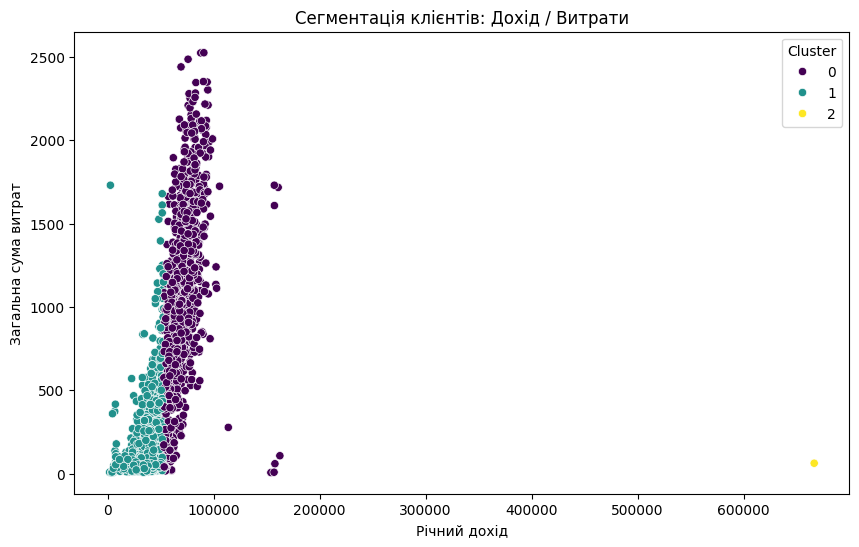

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Cluster'] = clusters

df['Total_Spent'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='Total_Spent', hue='Cluster', palette='viridis')

plt.title('Сегментація клієнтів: Дохід / Витрати')
plt.xlabel('Річний дохід')
plt.ylabel('Загальна сума витрат')
plt.show()

Така кластеризація даних має сенс лише для грубого поділу за рівнем доходу.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_scaled = kmeans_scaled.fit_predict(X_scaled)

score_scaled = silhouette_score(X_scaled, clusters_scaled)
print(f"Коефіцієнт силуету: {score_scaled:.4f}")

Коефіцієнт силуету: 0.1576


Після масштабування всі ознаки отримали рівну вагу. Зниження метрики до 0.1576 вказує на те, що кластери сильніше перекриваються.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [11]:
df_cleaned = df[(df['Income'] < 200000) & (df['Year_Birth'] > 1900)].copy()

print(f"Видалено записів: {len(df) - len(df_cleaned)}")

Видалено записів: 4


**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

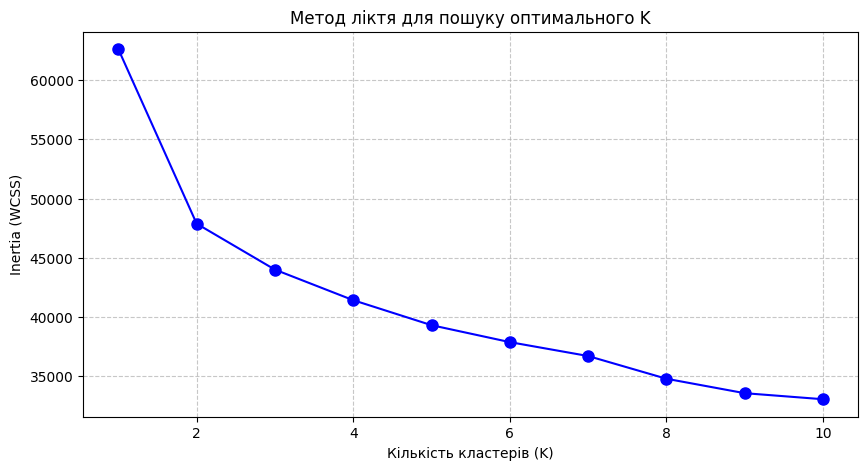

In [19]:
import numpy as np

X = df_cleaned.drop(columns=['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, 'bo-', markersize=8)
plt.title('Метод ліктя для пошуку оптимального K')
plt.xlabel('Кількість кластерів (K)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Оптимальна кількість кластерів: 3
Метрика силуету для K=3: 0.1813


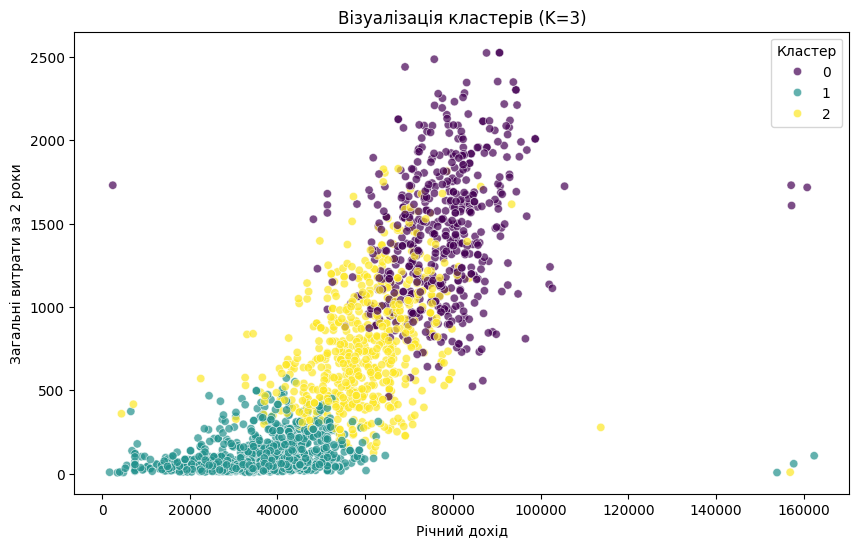

In [27]:
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cleaned['Cluster'] = kmeans_final.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df_cleaned['Cluster'])
print(f"Оптимальна кількість кластерів: {optimal_k}")
print(f"Метрика силуету для K={optimal_k}: {sil_score:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='Income', y='Total_Spent', hue='Cluster', palette='viridis', alpha=0.7)
plt.title(f'Візуалізація кластерів (K={optimal_k})')
plt.xlabel('Річний дохід')
plt.ylabel('Загальні витрати за 2 роки')
plt.legend(title='Кластер')
plt.show()

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

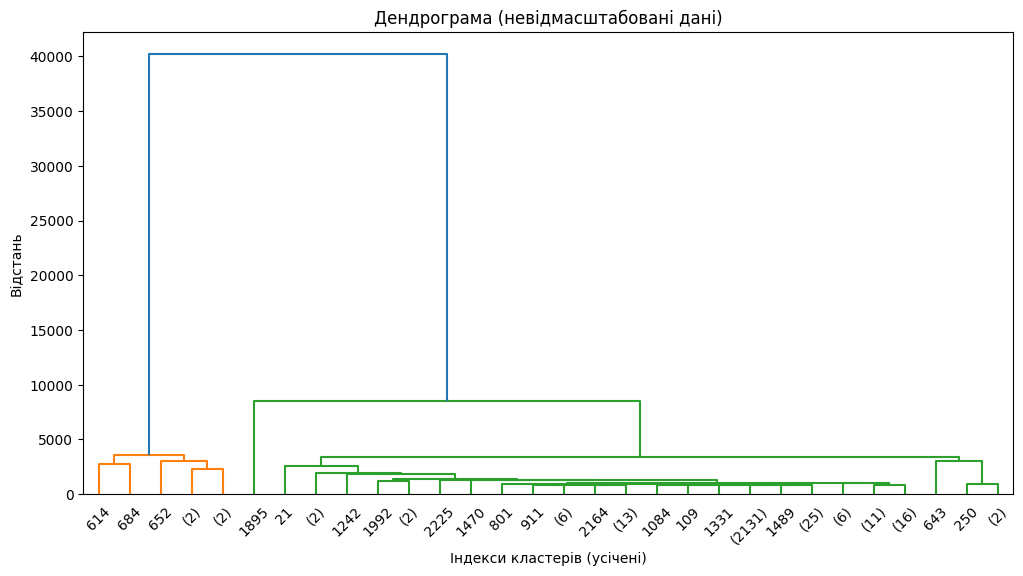

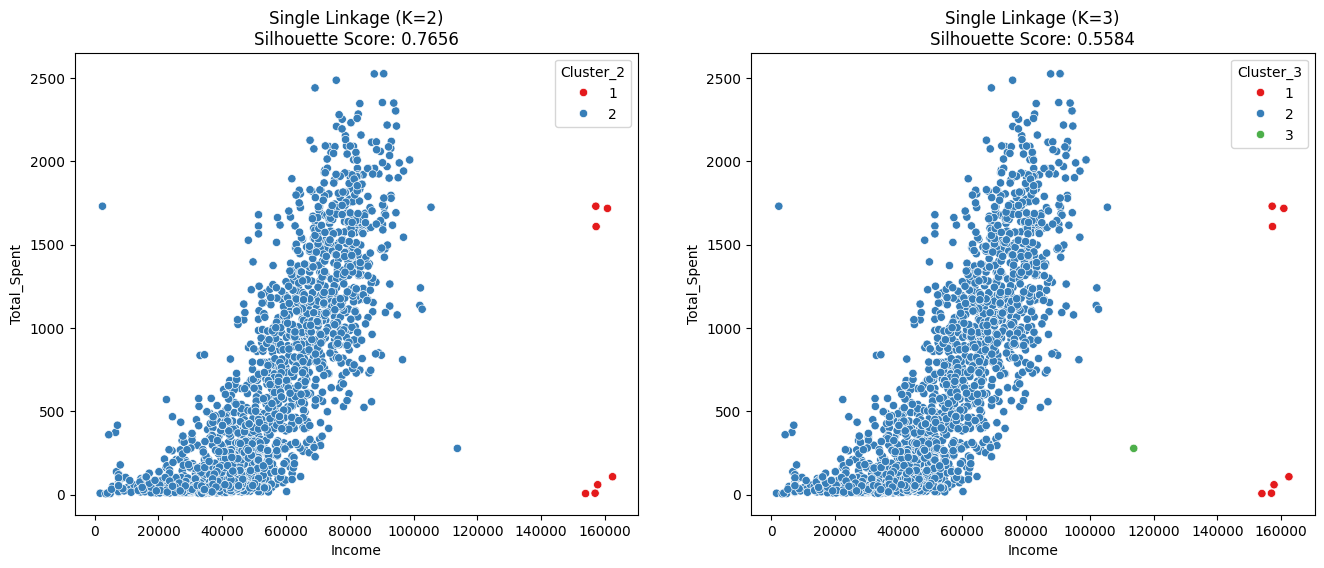

Розподіл об'єктів (K=2):
Cluster_2
2    2229
1       7
Name: count, dtype: int64
Розподіл об'єктів (K=3):
Cluster_3
2    2228
1       7
3       1
Name: count, dtype: int64


In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

X = df_cleaned.drop(columns=['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'], errors='ignore')

Z = linkage(X, method='single')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Дендрограма (невідмасштабовані дані)')
plt.xlabel('Індекси кластерів (усічені)')
plt.ylabel('Відстань')
plt.show()

df_cleaned['Cluster_2'] = fcluster(Z, 2, criterion='maxclust')
df_cleaned['Cluster_3'] = fcluster(Z, 3, criterion='maxclust')

sil_2 = silhouette_score(X, df_cleaned['Cluster_2'])
sil_3 = silhouette_score(X, df_cleaned['Cluster_3'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_cleaned, x='Income', y='Total_Spent', hue='Cluster_2', palette='Set1', ax=ax1)
ax1.set_title(f'Single Linkage (K=2)\nSilhouette Score: {sil_2:.4f}')

sns.scatterplot(data=df_cleaned, x='Income', y='Total_Spent', hue='Cluster_3', palette='Set1', ax=ax2)
ax2.set_title(f'Single Linkage (K=3)\nSilhouette Score: {sil_3:.4f}')

plt.show()

print(f"Розподіл об'єктів (K=2):\n{df_cleaned['Cluster_2'].value_counts()}")
print(f"Розподіл об'єктів (K=3):\n{df_cleaned['Cluster_3'].value_counts()}")

Кластеризація на невідмасштабованих даних у цьому випадку є невдалою. Вона не дозволяє виділити корисні профілі клієнтів.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

Метрика силуету: 0.1611


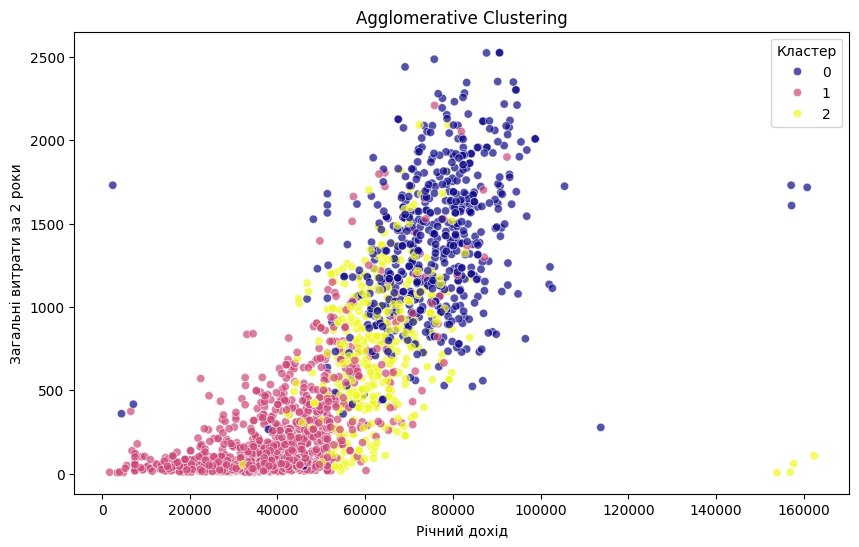

Cluster_Ward
1    1242
0     590
2     404
Name: count, dtype: int64


In [41]:
from sklearn.cluster import AgglomerativeClustering

agg_cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_cleaned['Cluster_Ward'] = agg_cluster.fit_predict(X_scaled)

sil_ward = silhouette_score(X_scaled, df_cleaned['Cluster_Ward'])
print(f"Метрика силуету: {sil_ward:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='Income', y='Total_Spent', hue='Cluster_Ward', palette='plasma', alpha=0.7)
plt.title('Agglomerative Clustering')
plt.xlabel('Річний дохід')
plt.ylabel('Загальні витрати за 2 роки')
plt.legend(title='Кластер')
plt.show()

print(df_cleaned['Cluster_Ward'].value_counts())

Дана кластеризація є корисною з практичної точки зору. Сформовано три великі групи клієнтів.